# 药品销售数据分析

对药品每日销售数据进行分析，包括总销售量、指定月份 Top3、日均销售量和月度趋势图。

In [31]:
# 导入所需模块
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文字体，避免图表中文乱码
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

## 1. 数据加载

读取 CSV 文件，将日期列转为 datetime 格式，并提取药品列（去掉后四列辅助列）。

In [32]:
def load_data():
    """加载并预处理药品销售数据"""
    # 读取 CSV 文件
    raw_df = pd.read_csv('salesdaily.csv')

    # 将日期列转换为 datetime 格式
    raw_df['datum'] = pd.to_datetime(raw_df['datum'])

    # 提取所有列名，去掉第一列（日期）和最后四列（Year/Month/Hour/Weekday Name）
    all_columns = raw_df.columns.tolist()
    drug_columns = all_columns[1:-4]  # 仅保留药品名称列

    return raw_df, drug_columns

In [33]:
# 加载数据并查看
full_df, drug_columns = load_data()
print(full_df)

          datum  M01AB   M01AE  N02BA  N02BE  N05B  N05C   R03   R06  Year  \
0    2014-01-02   0.00   3.670   3.40  32.40   7.0   0.0   0.0  2.00  2014   
1    2014-01-03   8.00   4.000   4.40  50.60  16.0   0.0  20.0  4.00  2014   
2    2014-01-04   2.00   1.000   6.50  61.85  10.0   0.0   9.0  1.00  2014   
3    2014-01-05   4.00   3.000   7.00  41.10   8.0   0.0   3.0  0.00  2014   
4    2014-01-06   5.00   1.000   4.50  21.70  16.0   2.0   6.0  2.00  2014   
...         ...    ...     ...    ...    ...   ...   ...   ...   ...   ...   
2101 2019-10-04   7.34   5.683   2.25  22.45  13.0   0.0   1.0  1.00  2019   
2102 2019-10-05   3.84   5.010   6.00  25.40   7.0   0.0   0.0  0.33  2019   
2103 2019-10-06   4.00  11.690   2.00  34.60   6.0   0.0   5.0  4.20  2019   
2104 2019-10-07   7.34   4.507   3.00  50.80   6.0   0.0  10.0  1.00  2019   
2105 2019-10-08   0.33   1.730   0.50  44.30  20.0   2.0   2.0  0.00  2019   

      Month  Hour Weekday Name  
0         1   248     Thursday

## 2. 总销售量分析

计算样本期内所有药品的总销售量，从高到低排序，并输出销量最高的药品。

In [34]:
def calc_total_sales(df, columns):
    """计算各药品总销售量并排序"""
    # 对样本期内所有药品的销售量求和，按降序排列
    total_sales = df[columns].sum().sort_values(ascending=False)

    # 打印所有药品的销售总量
    print(total_sales.to_string())

    # 打印销量最高的药品名称和销售量
    print(f"\n总销售量最高的药品: {total_sales.idxmax()} ({total_sales.max():.2f} units)")

    return total_sales

In [35]:
# 执行总销售量分析
total_sales_result = calc_total_sales(full_df, drug_columns)

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333

总销售量最高的药品: N02BE (63005.40 units)


## 3. 指定月份销量 Top3

按指定年月筛选数据，输出该月销量 Top3 药品；同时输出指定年份全年销量最高的药品。

In [36]:
def calc_top3_monthly_sales(df, columns, target_months, full_year):
    """计算指定月份的销量 Top3 及指定年份的全年最高销量药品"""
    # 遍历目标月份字典，计算每月销量 Top3
    for year, month in target_months.items():
        year = int(year)
        month = int(month)

        # 按年月筛选数据
        month_mask = (df['datum'].dt.year == year) & (df['datum'].dt.month == month)
        month_data = df.loc[month_mask, columns]

        # 对该月各药品销量求和，取 Top3
        month_top3 = month_data.sum().sort_values(ascending=False).head(3)
        print(f"\n{year}年{month}月销量 Top3:")
        print(month_top3)

    # 筛选指定年份的全年数据
    year_mask = df['datum'].dt.year == full_year
    year_data = df.loc[year_mask, columns]

    # 计算全年各药品总销量并排序
    year_totals = year_data.sum().sort_values(ascending=False)
    print(f"\n{full_year}年全年销量最高的药品: {year_totals.idxmax()} ({year_totals.max():.2f} units)")

In [37]:
# 指定要分析的年月：2015年1月、2016年7月、2017年9月
target_months = {'2015': '1', '2016': '7', '2017': '9'}
calc_top3_monthly_sales(full_df, drug_columns, target_months=target_months, full_year=2017)


2015年1月销量 Top3:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

2016年7月销量 Top3:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

2017年9月销量 Top3:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64

2017年全年销量最高的药品: N02BE (9258.80 units)


## 4. 日均销售量分析

计算每种药品的日均销售量，找出日均销量最高的药品。

In [38]:
def calc_daily_avg_sales(df, columns):
    """计算各药品的日均销售量"""
    # 计算每种药品的日均销量并降序排列
    daily_avg = df[columns].mean().sort_values(ascending=False)

    # 打印日均销量最高的药品
    print(f"日均销售量最高的药品: {daily_avg.idxmax()} ({daily_avg.max():.2f} units)")
    return daily_avg

In [39]:
# 执行日均销售量分析
daily_avg_result = calc_daily_avg_sales(full_df, drug_columns)

日均销售量最高的药品: N02BE (29.92 units)


## 5. 月度销量趋势图

绘制 R03 药品各月总销量的折线图，观察季节性趋势。

In [40]:
def plot_monthly_sales(df):
    """绘制 R03 药品的月度销量趋势折线图"""
    # 按月份分组汇总 R03 药品的销量
    monthly_r03_sales = df.groupby('Month')['R03'].sum()
    # print(monthly_r03_sales.to_string())
    # 绘制折线图
    plt.figure(figsize=(12, 7))
    plt.plot(monthly_r03_sales.index, monthly_r03_sales.values,
             marker='o', linestyle='-', color='blue', linewidth=2)
    plt.title('R03 药品月度销量趋势图', fontsize=14, fontweight='bold')
    plt.xlabel('月份 (1=1月, 12=12月)', fontsize=12)
    plt.ylabel('总销售量', fontsize=12)
    plt.xticks(range(1, 13))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.fill_between(monthly_r03_sales.index, monthly_r03_sales.values,
                     color='blue', alpha=0.1)
    plt.tight_layout()
    plt.show()

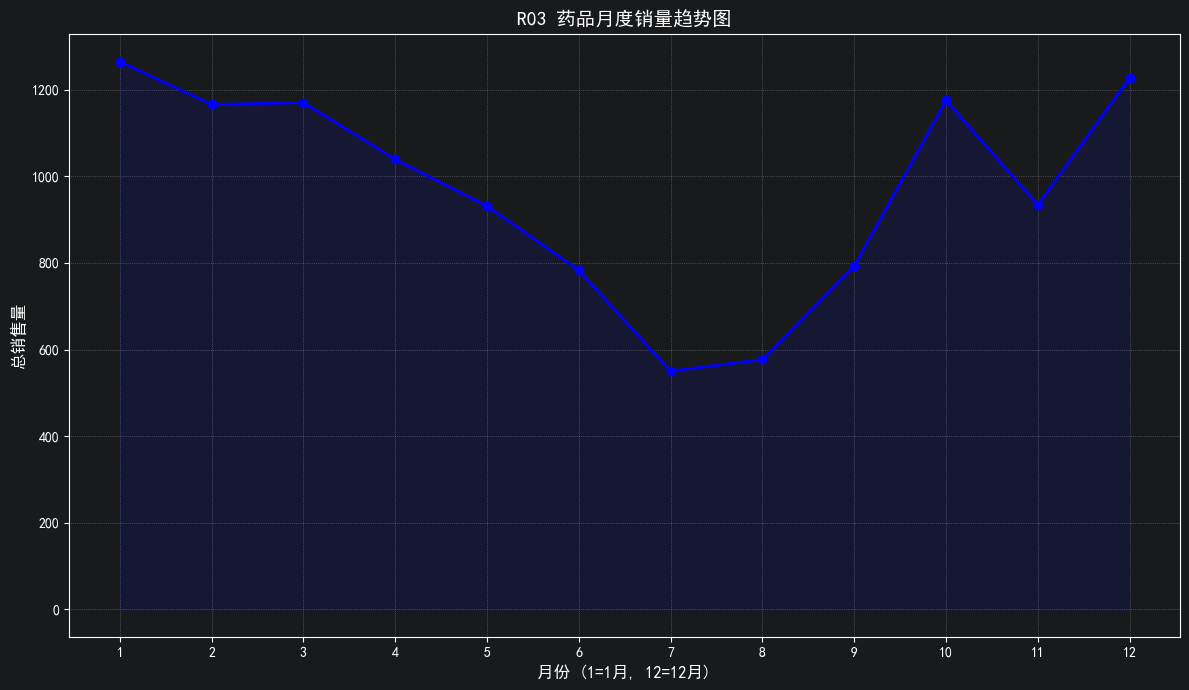

In [41]:
# 绘制月度销量趋势图
plot_monthly_sales(full_df)